<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/2_Empirical_Diagnostic_of_Custom_Weight_Initializations_and_Gradient_Vanishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
batch_size = 64
input_dim = 128

X = torch.randn(batch_size, input_dim)

print("Input Shape:", X.shape)

Input Shape: torch.Size([64, 128])


In [3]:
def xavier_init(in_features, out_features):
    limit = np.sqrt(6 / (in_features + out_features))
    return torch.empty(in_features, out_features).uniform_(-limit, limit)

In [4]:
def he_init(in_features, out_features):
    std = np.sqrt(2 / in_features)
    return torch.randn(in_features, out_features) * std

In [5]:
layers = 20
hidden_dim = 128

weights_xavier = []
weights_he = []

for i in range(layers):

    if i == 0:
        in_dim = input_dim
    else:
        in_dim = hidden_dim

    weights_xavier.append(xavier_init(in_dim, hidden_dim))
    weights_he.append(he_init(in_dim, hidden_dim))

In [6]:
def forward_pass(x, weights):

    activations = []
    means = []
    variances = []

    out = x

    for w in weights:

        out = torch.matmul(out, w)
        out = torch.relu(out)

        activations.append(out)
        means.append(out.mean().item())
        variances.append(out.var().item())

    return activations, means, variances

In [7]:
def gradient_analysis(activations):

    gradients = []

    grad = torch.ones_like(activations[-1])

    gradients.append(grad.abs().mean().item())

    for act in reversed(activations[:-1]):

        grad = grad * (act > 0).float()

        gradients.append(grad.abs().mean().item())

    gradients.reverse()

    return gradients

In [8]:
acts_x, mean_x, var_x = forward_pass(X, weights_xavier)

grad_x = gradient_analysis(acts_x)

In [9]:
acts_h, mean_h, var_h = forward_pass(X, weights_he)

grad_h = gradient_analysis(acts_h)

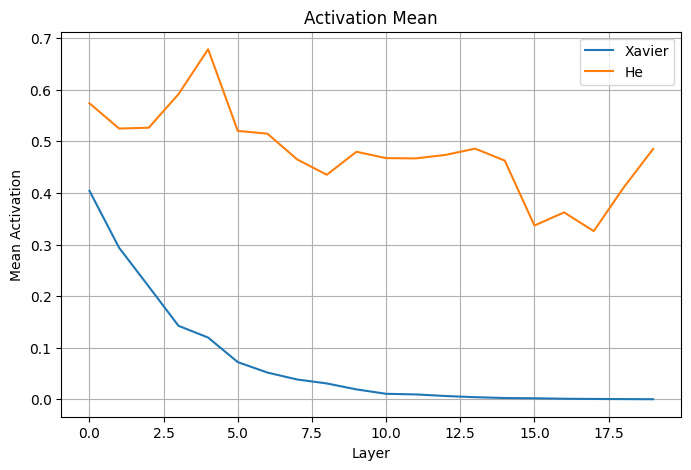

In [10]:
plt.figure(figsize=(8,5))

plt.plot(mean_x,label="Xavier")

plt.plot(mean_h,label="He")

plt.xlabel("Layer")

plt.ylabel("Mean Activation")

plt.title("Activation Mean")

plt.legend()

plt.grid(True)

plt.show()

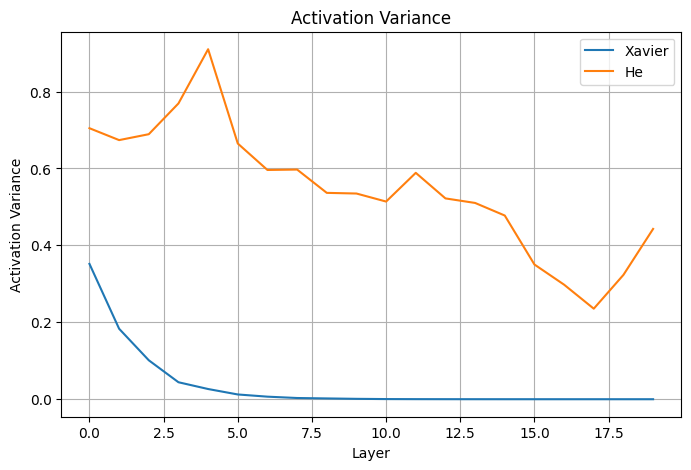

In [11]:
plt.figure(figsize=(8,5))

plt.plot(var_x,label="Xavier")

plt.plot(var_h,label="He")

plt.xlabel("Layer")

plt.ylabel("Activation Variance")

plt.title("Activation Variance")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
print("Xavier Initialization")
print("----------------------")
print("Final Mean :", mean_x[-1])
print("Final Variance :", var_x[-1])
print("Final Gradient :", grad_x[-1])

print()

print("He Initialization")
print("-----------------")
print("Final Mean :", mean_h[-1])
print("Final Variance :", var_h[-1])
print("Final Gradient :", grad_h[-1])

Xavier Initialization
----------------------
Final Mean : 0.0002958237600978464
Final Variance : 2.2954486667003948e-07
Final Gradient : 1.0

He Initialization
-----------------
Final Mean : 0.4850703477859497
Final Variance : 0.44275328516960144
Final Gradient : 1.0
